<H1> CS5143- NLP Spring 2026 <H1>

<H2> Programming assignment to build a three class classifier for sentiment analysis <H2>


<H3> Setup & Data Loading <H3>

In [52]:
# ==================================
# 1. IMPORT LIBRARIES
# ==================================
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight


In [ ]:
# ==================================
# 2. LOAD DATASET
# ==================================

DATA_PATH = r"C:\Users\Syeda Ravia Ejaz\OneDrive\Desktop\MSCS\Semester 3\NLP\Twitter_Sentiment_Classification\Twitter_Data.csv"
df = pd.read_csv(DATA_PATH)
print("Initial shape:", df.shape)

Initial shape: (162980, 2)


In [54]:
# ==================================
# 3. DROP MISSING VALUES
# ==================================
df = df.dropna(subset=["category"]).copy()
print("After dropping missing:", df.shape)


After dropping missing: (162973, 2)


In [55]:
# =========================
# 4. TEXT CLEANING
# =========================
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags (#word → word)
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Apply cleaning
df['clean_text'] = df['clean_text'].apply(clean_text)

In [56]:
# =========================
# 5. ENCODE LABELS
# =========================

label_map = {-1.0: 0, 0.0: 1, 1.0: 2}              # Original labels: -1, 0, 1 → convert to 0, 1, 2
df['category'] = df['category'].map(label_map)
print(df.head())
print("Label distribution:\n", df['category'].value_counts())


                                          clean_text  category
0  when modi promised “minimum government maximum...         0
1  talk all the nonsense and continue all the dra...         1
2  what did just say vote for modi welcome bjp to...         2
3  asking his supporters prefix chowkidar their n...         2
4  answer who among these the most powerful world...         2
Label distribution:
 category
2    72250
1    55213
0    35510
Name: count, dtype: int64


<H3> Train/Validation/Test Split (Stratified) <H3>

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    df['clean_text'],
    df['category'],
    test_size=0.3,
    random_state=42,
    stratify=df['category']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)
# Result: ~70% train, 10% val, 20% test

print(len(X_train), len(X_val), len(X_test))

114081 16297 32595


<H3> Baseline: TF-IDF + Naive Bayes (with χ² feature selection)<H3>

============== PERFORMANCE EVALUATION OF NAIVE BAYES CLASSIFIER ==============

Baseline (Val) Acc: 0.6994538872185064
Baseline (Val) Macro-F1: 0.6510853280919883
              precision    recall  f1-score   support

           0      0.899     0.341     0.495      3551
           1      0.851     0.607     0.709      5521
           2      0.621     0.946     0.750      7225

    accuracy                          0.699     16297
   macro avg      0.790     0.632     0.651     16297
weighted avg      0.759     0.699     0.680     16297

Baseline (Test) Acc: 0.7030526154318147
Baseline (Test) Macro-F1: 0.6565156761906493
              precision    recall  f1-score   support

           0      0.903     0.354     0.508      7102
           1      0.849     0.606     0.708     11043
           2      0.625     0.949     0.754     14450

    accuracy                          0.703     32595
   macro avg      0.792     0.636     0.657     32595
weighted avg      0.762     0.703     0.685  

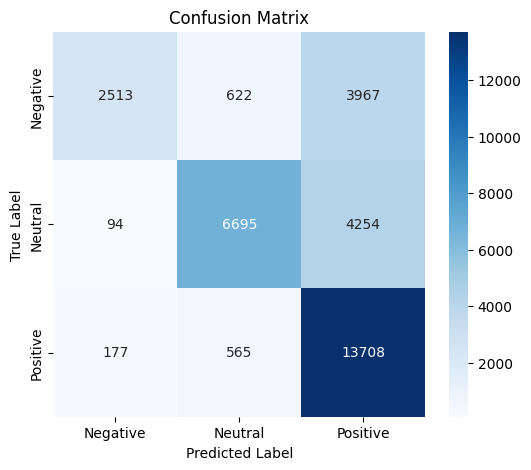

In [58]:
# =========================
# TF-IDF FEATURES
# =========================
baseline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2), #unigram + bigram
        min_df=5,
        max_df=0.9,
        sublinear_tf=True,
        strip_accents="unicode"
    )),
    ("chi2", SelectKBest(chi2, k="all")),      #used chi square feature selection method in naive bayes classifier
    ("clf", MultinomialNB())
])

# =========================
# TRAINING
# =========================
baseline.fit(X_train, y_train)

# =========================
# PREDICTION
# =========================
pred_val = baseline.predict(X_val)

# ================================
# EVALUATION ON VALIDATION DATA
# ================================
print("============== PERFORMANCE EVALUATION OF NAIVE BAYES CLASSIFIER ==============\n")
print("Baseline (Val) Acc:", accuracy_score(y_val, pred_val))
print("Baseline (Val) Macro-F1:", f1_score(y_val, pred_val, average="macro"))
print(classification_report(y_val, pred_val, digits=3))

# ================================
# EVALUATION ON TEST DATA
# ================================
pred_test = baseline.predict(X_test)
print("Baseline (Test) Acc:", accuracy_score(y_test, pred_test))
print("Baseline (Test) Macro-F1:", f1_score(y_test, pred_test, average="macro"))
print(classification_report(y_test, pred_test, digits=3))

# Compute confusion matrix
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

<H3> Keras Model: Tokenizer + Embedding + CNN + BiLSTM (Hybrid) <H3>

In [59]:
# Tokenization
VOCAB_SIZE = 40000
MAX_LEN = 64
tokenizer = keras.preprocessing.text.Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def vectorize(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return keras.preprocessing.sequence.pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

Xtr = vectorize(X_train)
Xva = vectorize(X_val)
Xte = vectorize(X_test)

# One-hot labels for softmax training
ytr = to_categorical(y_train, num_classes=3)
yva = to_categorical(y_val, num_classes=3)
yte = to_categorical(y_test, num_classes=3)

# Model skeleton
def build_model(vocab_size=VOCAB_SIZE, emb_dim=128, max_len=MAX_LEN, num_classes=3):
    inputs = keras.Input(shape=(max_len,), dtype="int32")

    # Embedding
    x = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim)(inputs)
    x = layers.SpatialDropout1D(0.3)(x)
    # CNN Block (captures local patterns)
    x = layers.Conv1D(filters=128, kernel_size=3, activation="relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # BiLSTM Block (captures sequence)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)

    # Dense layers
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_model()
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 64, 128)        │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 64, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 62, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,276,547 (20.13 MB)

 Trainable params: 5,276,547 (20.13 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

history = model.fit(
    Xtr, ytr,
    validation_data=(Xva, yva),
    epochs=12,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
892/892 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7738 - loss: 0.5465 - val_accuracy: 0.9415 - val_loss: 0.1948
Epoch 2/12
892/892 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9540 - loss: 0.1523 - val_accuracy: 0.9621 - val_loss: 0.1355
Epoch 3/12
892/892 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9717 - loss: 0.0985 - val_accuracy: 0.9615 - val_loss: 0.1270
Epoch 4/12
892/892 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9792 - loss: 0.0744 - val_accuracy: 0.9634 - val_loss: 0.1362
Epoch 5/12
892/892 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9830 - loss: 0.0604 - val_accuracy: 0.9619 - val_loss: 0.1413
Epoch 6/12
892/892 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9859 - loss: 0.0497 - val_accuracy: 0.9629 - val_loss: 0.1556


1019/1019 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
Keras (Test) Acc: 0.9622334713913177
Keras (Test) Macro-F1: 0.9585509760462999
              precision    recall  f1-score   support

           0      0.916     0.948     0.931      7102
           1      0.994     0.966     0.980     11043
           2      0.962     0.967     0.964     14450

    accuracy                          0.962     32595
   macro avg      0.957     0.960     0.959     32595
weighted avg      0.963     0.962     0.962     32595



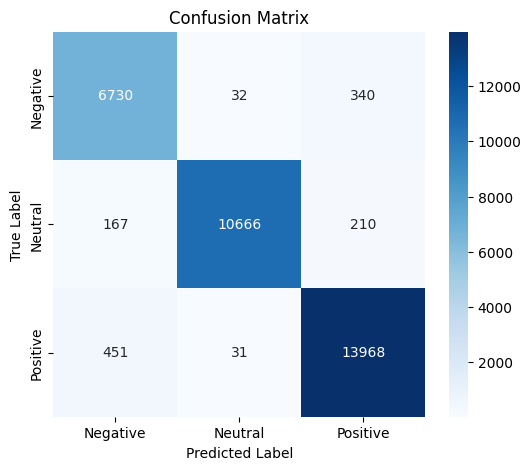

In [61]:
# Predictions and metrics
probs = model.predict(Xte)
y_pred = probs.argmax(axis=1)
y_true = y_test.values  # shape (N,)

print("Keras (Test) Acc:", accuracy_score(y_true, y_pred))
print("Keras (Test) Macro-F1:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, digits=3))
# print("Confusion Matrix (Test):\n", confusion_matrix(y_true, y_pred))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

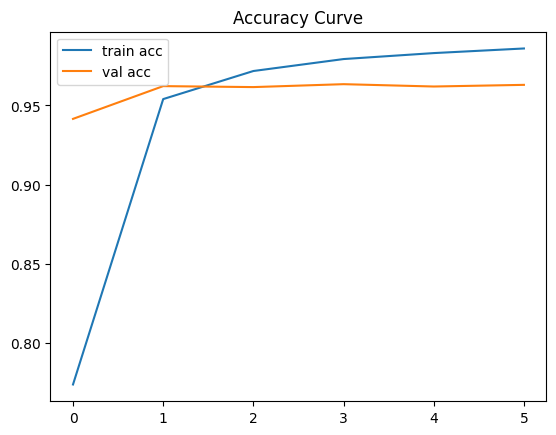

In [62]:
misclassified = misclassified[misclassified['true'] != misclassified['pred']]

misclassified.sample(5)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()
model.save("sentiment_lstm.h5")

import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

(162980, 2)
                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64
label
2    72249
1    55210
0    35509
Name: count, dtype: int64
Naive Bayes Accuracy: 0.6915076394428422

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.41      0.55      7102
           1       0.79      0.60      0.68     11042
           2       0.63      0.90      0.74     14450

    accuracy                           0.69     32594
   macro avg       0.75      0.64      0.66     32594
weighted avg       0.73      0.69      0.68     32594



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
917/917 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8665 - loss: 0.3566 - val_accuracy: 0.9518 - val_loss: 0.1566
Epoch 2/5
917/917 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9682 - loss: 0.1102 - val_accuracy: 0.9587 - val_loss: 0.1368
Epoch 3/5
917/917 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9798 - loss: 0.0701 - val_accuracy: 0.9624 - val_loss: 0.1322
Epoch 4/5
917/917 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9842 - loss: 0.0525 - val_accuracy: 0.9649 - val_loss: 0.1419
Epoch 5/5
917/917 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9875 - loss: 0.0387 - val_accuracy: 0.9626 - val_loss: 0.1676
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
Neural Network Accuracy: 0.9665275817635147

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      7102
           1       0.99      0.97      0.98     11042
           2       0.96      0.98      0.97     14450

    accuracy             

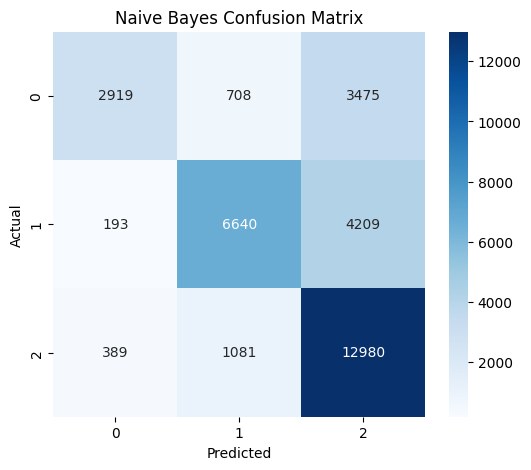

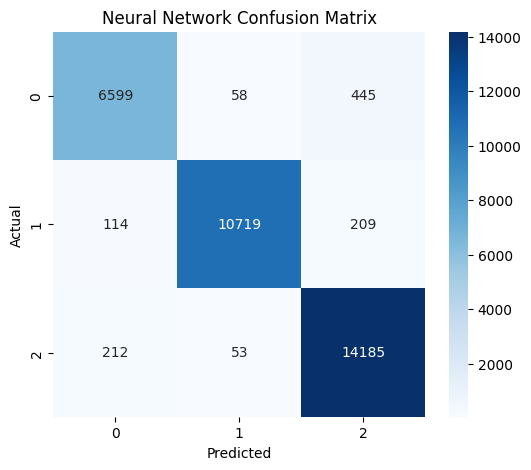

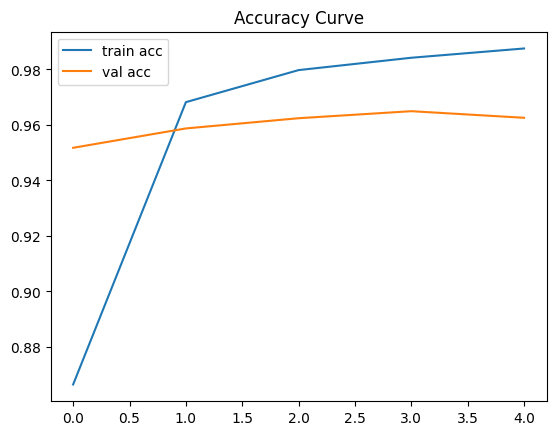

In [63]:
df = pd.read_csv("/content/Twitter_Data.csv")

print(df.shape)
print(df.head())
print(df['category'].value_counts())
df = df.dropna(subset=['clean_text', 'category'])

# Convert labels to integers
df['category'] = df['category'].astype(int)

# Map labels (-1,0,1) → (0,1,2)
label_map = {-1: 0, 0: 1, 1: 2}
df['label'] = df['category'].map(label_map)

print(df['label'].value_counts())
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
max_vocab = 50000
max_len = 50

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')
model = Sequential([
    Embedding(input_dim=max_vocab, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128
)
y_pred_nn = model.predict(X_test_pad)
y_pred_nn = np.argmax(y_pred_nn, axis=1)

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(y_test, y_pred_nb, "Naive Bayes Confusion Matrix")
plot_conf_matrix(y_test, y_pred_nn, "Neural Network Confusion Matrix")
misclassified = pd.DataFrame({
    'text': X_test.values,
    'true': y_test.values,
    'pred': y_pred_nn
})

misclassified = misclassified[misclassified['true'] != misclassified['pred']]

misclassified.sample(5)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()
model.save("sentiment_lstm.h5")

import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
